# Continuous vs. Discrete Time Stochastic System Simulation

## Learning Objectives
* Understand the mathematical difference between Stochastic Differential Equations (SDEs) and Difference Equations.
* Learn how to simulate continuous-time processes using `sdeint`.
* Implement discrete-time approximations (Euler-Maruyama) manually.
* **New:** Propagate and verify covariance for both continuous and discrete cases.
* Visualize and compare the path properties of continuous vs. discrete simulation.

## 1. Theoretical Background

### Continuous-Time Dynamics (SDEs)
A continuous-time stochastic system differs from an Ordinary Differential Equation (ODE) by the inclusion of a random noise term. It is formally written as a Stochastic Differential Equation (SDE):

$$
dX_t = f(X_t, t)dt + g(X_t, t)dW_t
$$

Where:
* $f(X_t, t)$ is the **drift** (deterministic part).
* $g(X_t, t)$ is the **diffusion** (stochastic part).
* $W_t$ is a **Wiener process** (Brownian motion), representing continuous-time noise.

For the linear case $dX_t = A X_t dt + G dW_t$, with noise spectral density $Q_c$ (where $\mathbb{E}[dW_t dW_t^T] = Q_c dt$), the covariance $P(t) = \mathbb{E}[(X_t - \mu_t)(X_t - \mu_t)^T]$ evolves according to the **Lyapunov Differential Equation**:

$$
\dot{P}(t) = A P(t) + P(t) A^T + G Q_c G^T
$$

### Discrete-Time Dynamics
To simulate this on a computer, we discretize using time step $\Delta t$. The system becomes:

$$
X_{k+1} = \Phi X_k + \Gamma W_k
$$

where $\Phi \approx I + A \Delta t$, $\Gamma \approx G$, and $W_k$ is discrete noise with covariance $Q_d \approx Q_c \Delta t$. 

The covariance propagation in discrete time is given by the algebraic update:

$$
P_{k+1} = \Phi P_k \Phi^T + Q_d'
$$

where $Q_d'$ is the discrete process noise covariance, often approximated as $G Q_c G^T \Delta t$ for small $\Delta t$.

In [1]:
# Install sdeint if not already installed
%pip install sdeint

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sdeint
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output
from scipy.integrate import odeint

# Set seed for reproducibility
np.random.seed(42)

%matplotlib inline

## 2. Continuous-Time Simulation

We will simulate a simple linear scalar SDE (Ornstein-Uhlenbeck Process):

$$
dX_t = -\theta X_t dt + \sigma dW_t
$$

Here $A = -\theta$ and $G = \sigma$. The noise strength is implicitly handled by `sdeint` using standard Brownian increments.

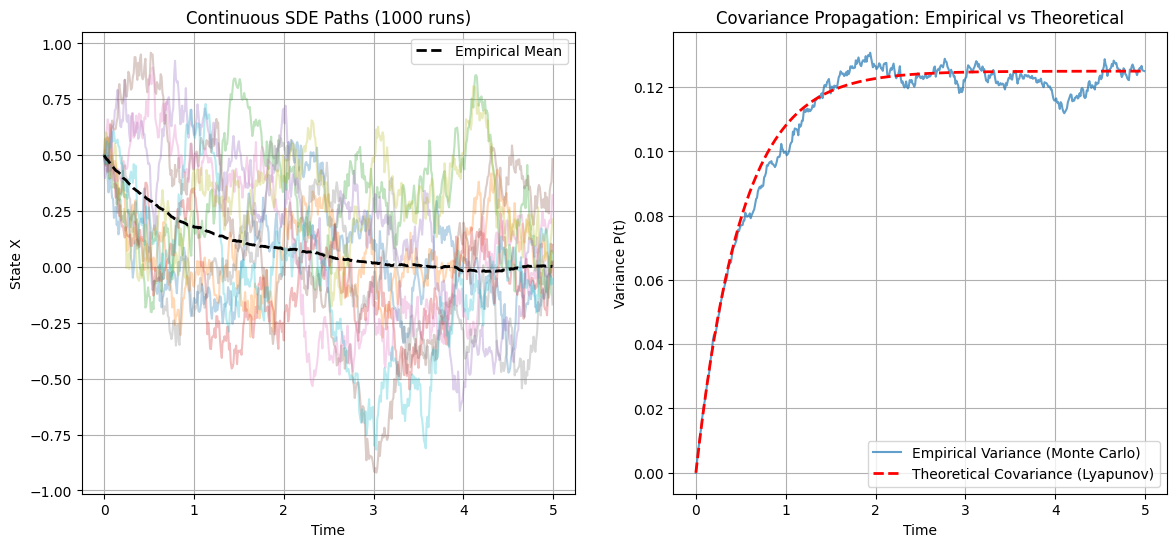

In [3]:
# System Parameters
theta = 1.0  # Mean reversion rate (>0 for stability)
sigma = 0.5  # Noise diffusion coefficient
x0 = 0.5     # Initial condition
P0 = 0.0     # Initial covariance (deterministic start)

# Time span
T = 5.0
dt_fine = 0.01
t_span = np.arange(0, T, dt_fine)

# 1. State Simulation (Stochastic)
# SDE: dX = f(x,t)dt + g(x,t)dW
def f(x, t): return -theta * x
def g(x, t): return sigma

# Generate multiple paths to estimate statistics empirically
num_paths = 1000
paths = np.zeros((len(t_span), num_paths))

for i in range(num_paths):
    # We reshape to flatten the result from sdeint which returns (N, 1)
    paths[:, i] = sdeint.itoint(f, g, x0, t_span).flatten()

# Calculate empirical variance from Monte Carlo runs
empirical_mean = np.mean(paths, axis=1)
empirical_var = np.var(paths, axis=1)

# 2. Covariance Propagation (Deterministic ODE)
# Lyapunov Equation: dP/dt = A P + P A^T + G Q G^T
# Here scalar: dP/dt = 2*(-theta)*P + sigma^2
def lyapunov_deriv(P, t):
    # P is variance in scalar case
    # Q_c is usually normalized to 1 in standard form if sigma is explicit
    # The noise term contribution is (sigma)^2
    return -2 * theta * P + sigma**2

theoretical_var = odeint(lyapunov_deriv, P0, t_span).flatten()

# Plotting Results
plt.figure(figsize=(14, 6))

# Subplot 1: Several Sample Paths
plt.subplot(1, 2, 1)
plt.plot(t_span, paths[:, :10], alpha=0.3)
plt.plot(t_span, empirical_mean, 'k--', label='Empirical Mean', linewidth=2)
plt.title(f'Continuous SDE Paths ({num_paths} runs)')
plt.xlabel('Time')
plt.ylabel('State X')
plt.grid(True)
plt.legend()

# Subplot 2: Variance Comparison
plt.subplot(1, 2, 2)
plt.plot(t_span, empirical_var, label='Empirical Variance (Monte Carlo)', alpha=0.7)
plt.plot(t_span, theoretical_var, 'r--', label='Theoretical Covariance (Lyapunov)', linewidth=2)
plt.title('Covariance Propagation: Empirical vs Theoretical')
plt.xlabel('Time')
plt.ylabel('Variance P(t)')
plt.grid(True)
plt.legend()

plt.show()

## 3. Discrete-Time Simulation and Covariance

Now we assume a discrete-time model with step size $\Delta t$.

**State Update:**
$x_{k+1} = (1 - \theta \Delta t) x_k + \sigma \sqrt{\Delta t} \, \xi_k$, where $\xi_k \sim \mathcal{N}(0,1)$.

**Covariance Update (Riccati / Algebraic):**
$P_{k+1} = \Phi P_k \Phi^T + Q_d$

Where:
* $\Phi = 1 - \theta \Delta t$
* $Q_d = \sigma^2 \Delta t$ (Approximation for small $\Delta t$)

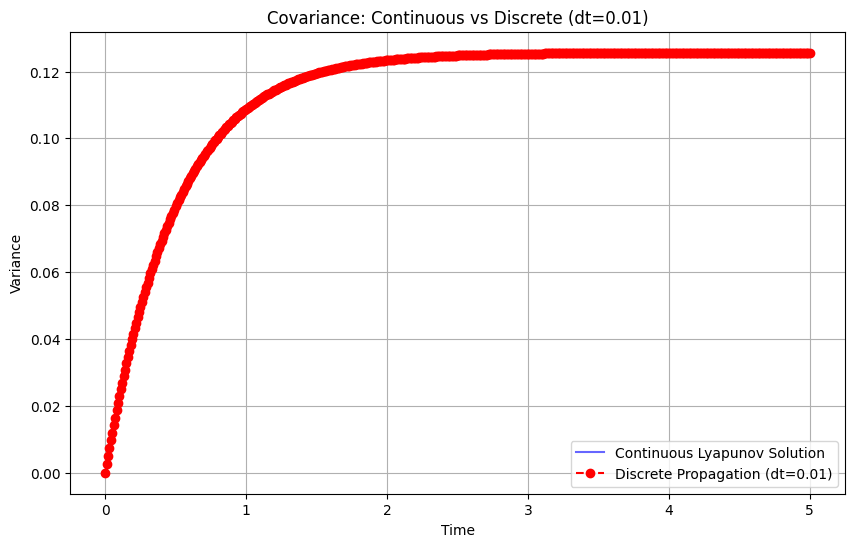

In [4]:
# Parameters for Discrete Simulation
dt_disc = 0.01
steps = int(T / dt_disc)
t_discrete = np.linspace(0, T, steps + 1)

# Matrices / Scalars
Phi = 1 - theta * dt_disc
Q_d = sigma**2 * dt_disc

# Storage
P_discrete = np.zeros(steps + 1)
P_discrete[0] = P0

# Covariance Propagation Loop
for k in range(steps):
    P_discrete[k+1] = Phi * P_discrete[k] * Phi + Q_d

# Plotting Comparison with Continuous Theoretical Result
plt.figure(figsize=(10, 6))
plt.plot(t_span, theoretical_var, 'b-', label='Continuous Lyapunov Solution', alpha=0.6)
plt.step(t_discrete, P_discrete, 'r--o', label=f'Discrete Propagation (dt={dt_disc})', where='post')
plt.title(f'Covariance: Continuous vs Discrete (dt={dt_disc})')
plt.xlabel('Time')
plt.ylabel('Variance')
plt.legend()
plt.grid(True)
plt.show()

## 4. Student Exercise

### Task
Modify the discrete time step `dt_disc` to `0.5` and observe the divergence between the discrete covariance propagation and the continuous Lyapunov solution. Why does the discrete approximation underestimate or overestimate the true variance for large steps?

### Challenge
For the discrete update $P_{k+1} = \Phi P_k \Phi + Q_d$, can you derive the steady-state variance ($P_{k+1} = P_k = P_{ss}$) algebraically? Compare it to the continuous steady state $P_{ss} = \sigma^2 / (2\theta)$.

### Why Does the Discrete Approximation Diverge for Large $\Delta t$?

The discrete covariance update uses the **first-order approximation**:

$$\Phi = 1 - \theta \Delta t, \quad Q_d \approx \sigma^2 \Delta t$$

This is valid only when $\theta \Delta t \ll 1$.  For larger $\Delta t$:

* $\Phi^2 = (1 - \theta \Delta t)^2$ underestimates state decay — the **discrete recursion accumulates more variance** than reality.
* The **steady-state** of the discrete recursion is $P_{ss}^{\text{disc}} = \dfrac{\sigma^2}{2\theta - \theta^2 \Delta t}$, which is **always larger** than the continuous value $P_{ss}^{\text{cont}} = \dfrac{\sigma^2}{2\theta}$ for any positive $\Delta t$.
* For $\Delta t \geq 2/\theta$ the matrix $\Phi^2 \geq 1$ and the recursion **diverges**.

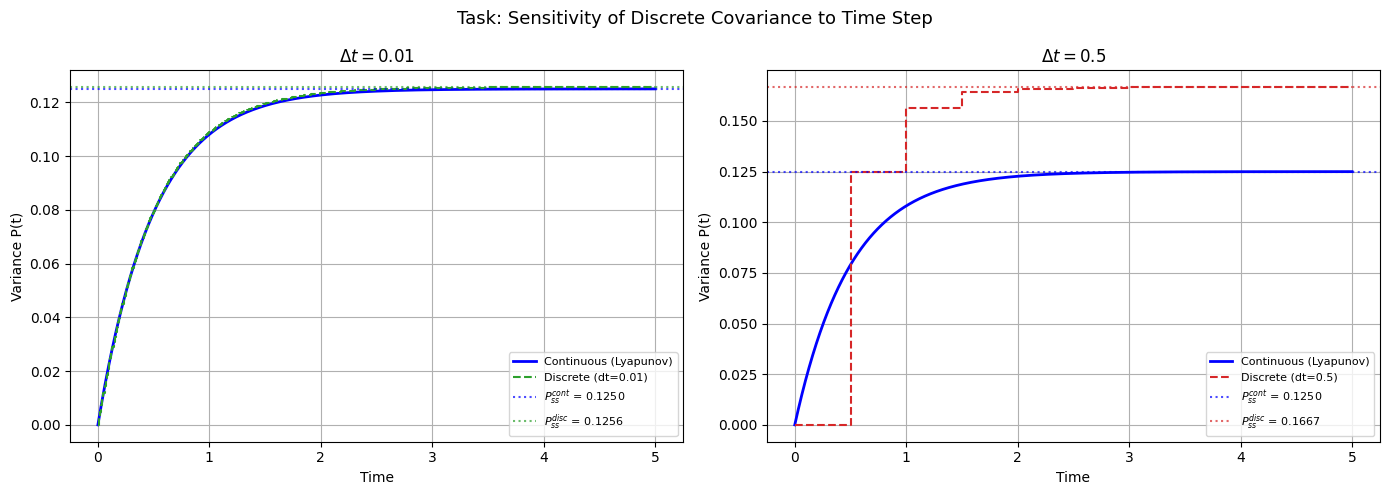

Continuous steady-state  P_ss = sigma^2/(2*theta)             = 0.125000
Discrete s-s (dt=0.01)   P_ss = sigma^2/(2*theta-theta^2*dt)  = 0.125628
Discrete s-s (dt=0.50)   P_ss = sigma^2/(2*theta-theta^2*dt)  = 0.166667

Error at dt=0.01: 0.000628
Error at dt=0.50: 0.041667


In [5]:
# ── Task Solution: compare covariance propagation for dt = 0.01 vs dt = 0.5 ──
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Parameters (inherited from earlier cells, redefined here for clarity)
theta = 1.0
sigma = 0.5
P0    = 0.0
T     = 5.0

# Continuous reference (Lyapunov ODE)
dt_fine = 0.001
t_cont  = np.arange(0, T, dt_fine)

def lyapunov_deriv(P, t):
    return -2 * theta * P + sigma**2

P_cont = odeint(lyapunov_deriv, P0, t_cont).flatten()

# ── Discrete propagation helper ──────────────────────────────────────────────
def discrete_cov_propagation(dt, theta, sigma, P0, T):
    steps = int(T / dt)
    t_arr = np.linspace(0, T, steps + 1)
    Phi   = 1.0 - theta * dt
    Q_d   = sigma**2 * dt
    P     = np.zeros(steps + 1)
    P[0]  = P0
    for k in range(steps):
        P[k + 1] = Phi**2 * P[k] + Q_d
    return t_arr, P

dt_small = 0.01
dt_large = 0.50

t_small, P_small = discrete_cov_propagation(dt_small, theta, sigma, P0, T)
t_large, P_large = discrete_cov_propagation(dt_large, theta, sigma, P0, T)

# Steady-state reference lines
Pss_cont  = sigma**2 / (2 * theta)
Pss_small = sigma**2 / (2 * theta - theta**2 * dt_small)
Pss_large = sigma**2 / (2 * theta - theta**2 * dt_large)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Task: Sensitivity of Discrete Covariance to Time Step', fontsize=13)

for ax, (t_d, P_d, dt_val, Pss_d, color) in zip(
    axes,
    [(t_small, P_small, dt_small, Pss_small, 'tab:green'),
     (t_large, P_large, dt_large, Pss_large, 'tab:red')],
):
    ax.plot(t_cont, P_cont, 'b-',  linewidth=2, label='Continuous (Lyapunov)')
    ax.step(t_d, P_d, '--', color=color, where='post', label=f'Discrete (dt={dt_val})')
    ax.axhline(Pss_cont, color='blue',  linestyle=':', alpha=0.7,
               label=f'$P_{{ss}}^{{cont}}$ = {Pss_cont:.4f}')
    ax.axhline(Pss_d,    color=color,   linestyle=':', alpha=0.7,
               label=f'$P_{{ss}}^{{disc}}$ = {Pss_d:.4f}')
    ax.set_title(f'$\\Delta t = {dt_val}$')
    ax.set_xlabel('Time')
    ax.set_ylabel('Variance P(t)')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.show()

print(f'Continuous steady-state  P_ss = sigma^2/(2*theta)             = {Pss_cont:.6f}')
print(f'Discrete s-s (dt=0.01)   P_ss = sigma^2/(2*theta-theta^2*dt)  = {Pss_small:.6f}')
print(f'Discrete s-s (dt=0.50)   P_ss = sigma^2/(2*theta-theta^2*dt)  = {Pss_large:.6f}')
print(f'\nError at dt=0.01: {abs(Pss_small - Pss_cont):.6f}')
print(f'Error at dt=0.50: {abs(Pss_large - Pss_cont):.6f}')

### Challenge: Steady-State Variance — Algebraic Derivation

#### Continuous Case

At steady state $\dot{P} = 0$, so the Lyapunov ODE gives:

$$0 = -2\theta P_{ss} + \sigma^2$$

$$\boxed{P_{ss}^{\text{cont}} = \dfrac{\sigma^2}{2\theta}}$$

#### Discrete Case

At steady state $P_{k+1} = P_k = P_{ss}$:

$$P_{ss} = \Phi^2 P_{ss} + Q_d \implies P_{ss}(1 - \Phi^2) = Q_d$$

Substituting $\Phi = 1 - \theta \Delta t$ and $Q_d = \sigma^2 \Delta t$:

$$1 - \Phi^2 = 1 - (1 - \theta \Delta t)^2 = 2\theta \Delta t - \theta^2 \Delta t^2$$

$$\boxed{P_{ss}^{\text{disc}} = \dfrac{\sigma^2 \Delta t}{2\theta \Delta t - \theta^2 \Delta t^2} = \dfrac{\sigma^2}{2\theta - \theta^2 \Delta t}}$$

* As $\Delta t \to 0$:  $P_{ss}^{\text{disc}} \to \dfrac{\sigma^2}{2\theta} = P_{ss}^{\text{cont}}$ ✓
* For $\Delta t = 2/\theta$: denominator $= 0$ → **divergence boundary**.
* For $\Delta t > 2/\theta$: denominator $< 0$ → **unstable / non-physical**.

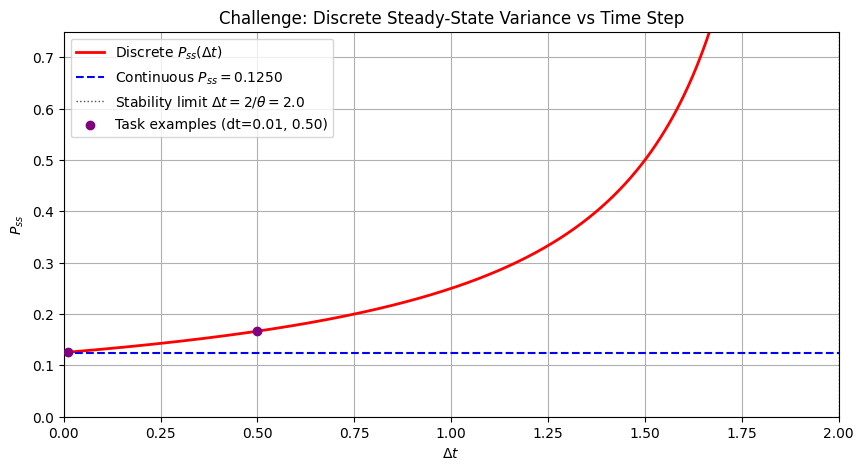

      dt     P_ss_disc   error vs cont
----------------------------------------
   0.001      0.125063        0.000063
   0.010      0.125628        0.000628
   0.100      0.131579        0.006579
   0.500      0.166667        0.041667
   1.000      0.250000        0.125000
   1.500      0.500000        0.375000
   1.900      2.500000        2.375000


In [6]:
# ── Challenge Solution: steady-state surface across dt values ───────────────
import numpy as np
import matplotlib.pyplot as plt

theta = 1.0
sigma = 0.5

Pss_cont = sigma**2 / (2 * theta)

# Stable range: dt < 2/theta
dt_max_stable = 2.0 / theta   # = 2.0 for theta=1
dt_vals = np.linspace(0.001, dt_max_stable * 0.99, 500)
Pss_disc = sigma**2 / (2 * theta - theta**2 * dt_vals)

plt.figure(figsize=(10, 5))
plt.plot(dt_vals, Pss_disc, 'r-', linewidth=2, label='Discrete $P_{ss}(\\Delta t)$')
plt.axhline(Pss_cont, color='blue', linestyle='--', linewidth=1.5,
            label=f'Continuous $P_{{ss}} = {Pss_cont:.4f}$')
plt.axvline(dt_max_stable, color='k', linestyle=':', linewidth=1, alpha=0.7,
            label=f'Stability limit $\\Delta t = 2/\\theta = {dt_max_stable:.1f}$')
plt.scatter([0.01, 0.50], 
            [sigma**2/(2*theta - theta**2*0.01),
             sigma**2/(2*theta - theta**2*0.50)],
            color='purple', zorder=5,
            label='Task examples (dt=0.01, 0.50)')
plt.xlim(0, dt_max_stable)
plt.ylim(0, Pss_cont * 6)
plt.title('Challenge: Discrete Steady-State Variance vs Time Step')
plt.xlabel('$\\Delta t$')
plt.ylabel('$P_{ss}$')
plt.legend()
plt.grid(True)
plt.show()

# Tabulate a few representative values
print(f'{"dt":>8}  {"P_ss_disc":>12}  {"error vs cont":>14}')
print('-' * 40)
for dt in [0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 1.9]:
    denom = 2 * theta - theta**2 * dt
    if denom > 0:
        Pss_d = sigma**2 / denom
        print(f'{dt:>8.3f}  {Pss_d:>12.6f}  {Pss_d - Pss_cont:>14.6f}')
    else:
        print(f'{dt:>8.3f}  {"UNSTABLE":>12}  {"─":>14}')

### Summary

| Property | Continuous (Lyapunov) | Discrete ($\\Delta t$ small) | Discrete ($\\Delta t$ large) |
|---|---|---|---|
| **State update** | $dX = -\\theta X\,dt + \\sigma\, dW$ | $x_{k+1} = \\Phi x_k + \\sigma\\sqrt{dt}\,\\xi_k$ | same formula, larger $dt$ |
| **Covariance ODE** | $\\dot{P} = -2\\theta P + \\sigma^2$ | $P_{k+1} = \\Phi^2 P_k + Q_d$ | same formula |
| **Steady state $P_{ss}$** | $\\sigma^2/(2\\theta)$ | $\\sigma^2/(2\\theta - \\theta^2 \\Delta t)$ (close) | overestimate / diverge |
| **Stability** | always stable ($\\theta > 0$) | stable iff $|\\Phi| < 1$ | unstable for $\\Delta t \\geq 2/\\theta$ |

**Key insight for estimation theory:** When implementing discrete Kalman filters, choose $\\Delta t$ small enough that $\\theta \\Delta t \\ll 1$, otherwise the predicted covariance $P_{k|k-1}$ will be inflated, leading to a filter that trusts the model less than it should.